# **LABORATORIO 2:** Tratamiento Matemático y Espectral del Preprocesamiento de Datos

En Ciencias de la Computación, la ingenuidad algorítmica se paga caro. Asumir que los datos del mundo real vienen listos para ser introducidos en un modelo matemático es el primer paso hacia el fracaso predictivo.

En este laboratorio, abandonaremos la visión puramente descriptiva o de "uso de librerías" para entrar de lleno en el **Tratamiento Matemático Espectral del Preprocesamiento de Datos**.



---


Este cuaderno no es un tutorial de programación; es un entorno de simulación algebraica. Aquí demostraremos empíricamente los teoremas presentados en la teoría y comprobaremos cómo las propiedades topológicas del hiperespacio de datos dictan el límite de rendimiento de cualquier algoritmo de aprendizaje estadístico.

---

### [CONFIGURACIÓN DEL ENTORNO]

In [ ]:
# ==============================================================================
# CONFIGURACIÓN INICIAL DEL ENTORNO
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import scipy.linalg as la

# Configuración de estilo riguroso para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

print("Entorno matemático configurado correctamente.")

Entorno matemático configurado correctamente.


## BLOQUE I: CALIDAD DE DATOS Y RUIDO





### 1. Objetivos Matemáticos

* Formalizar el modelo de ruido aditivo.
* Demostrar la inflación de los autovalores de la matriz de covarianza debido a perturbaciones gaussianas.
* Conectar el ensanchamiento espectral con la degradación del riesgo empírico.

### 2. Demostraciones Matemáticas

**Modelo Aditivo de Ruido:**
Supongamos que el vector de características latente y verdadero es $\mathbf{x}_{real}$. Sin embargo, nuestros sensores observan una variable contaminada $\mathbf{x}_{obs}$:


$$\mathbf{x}_{obs} = \mathbf{x}_{real} + \boldsymbol{\epsilon}$$


Asumimos que el ruido $\boldsymbol{\epsilon}$ es independiente de la señal, con media cero y distribución isotrópica: $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 I)$.

**Teorema de la Inflación Espectral:**
Queremos encontrar la matriz de covarianza de los datos observados $\Sigma_{obs}$.


$$\Sigma_{obs} = \mathbb{E}[(\mathbf{x}_{obs} - \boldsymbol{\mu}_{obs})(\mathbf{x}_{obs} - \boldsymbol{\mu}_{obs})^T]$$

$$\Sigma_{obs} = \mathbb{E}[((\mathbf{x}_{real} - \boldsymbol{\mu}_{real}) + \boldsymbol{\epsilon})((\mathbf{x}_{real} - \boldsymbol{\mu}_{real}) + \boldsymbol{\epsilon})^T]$$


Desarrollando y aplicando la linealidad del operador Esperanza $\mathbb{E}$, y sabiendo que la covarianza cruzada entre la señal y el ruido es nula ($\mathbb{E}[\mathbf{x}_{real}\boldsymbol{\epsilon}^T] = 0$):


$$\Sigma_{obs} = \Sigma_{real} + \mathbb{E}[\boldsymbol{\epsilon} \boldsymbol{\epsilon}^T]$$


Dado que $\mathbb{E}[\boldsymbol{\epsilon} \boldsymbol{\epsilon}^T]$ es la matriz de covarianza del ruido $\sigma^2 I$:


$$\Sigma_{obs} = \Sigma_{real} + \sigma^2 I$$

**Impacto en los Autovalores:**
Sea $\lambda_i$ un autovalor de $\Sigma_{real}$ asociado al autovector $\mathbf{v}_i$. En la matriz observada:


$$\Sigma_{obs}\mathbf{v}_i = (\Sigma_{real} + \sigma^2 I)\mathbf{v}_i = \Sigma_{real}\mathbf{v}_i + \sigma^2 I \mathbf{v}_i = \lambda_i \mathbf{v}_i + \sigma^2 \mathbf{v}_i = (\lambda_i + \sigma^2)\mathbf{v}_i$$


*Conclusión rigurosa:* El ruido isotrópico no cambia los ejes principales (autovectores) de la distribución, pero **infla todos sus autovalores artificialmente en $\sigma^2$**. Esto disfraza el ruido como varianza útil, engañando a algoritmos como PCA y elevando el riesgo empírico mínimo alcanzable (Cota de Cramer-Rao).

### 3. Implementación Computacional y Visualización

---

# [Simulación Sintética de Ruido e Inflación Espectral]

--- ANÁLISIS ESPECTRAL ---
Autovalores de Sigma_real: [0.5151 8.7845]
Autovalores de Sigma_obs : [195.2895 219.8453]
Diferencia teórica esperada (sigma^2) : 200.0
Diferencia empírica (Inflación)     : [194.7744 211.0608]


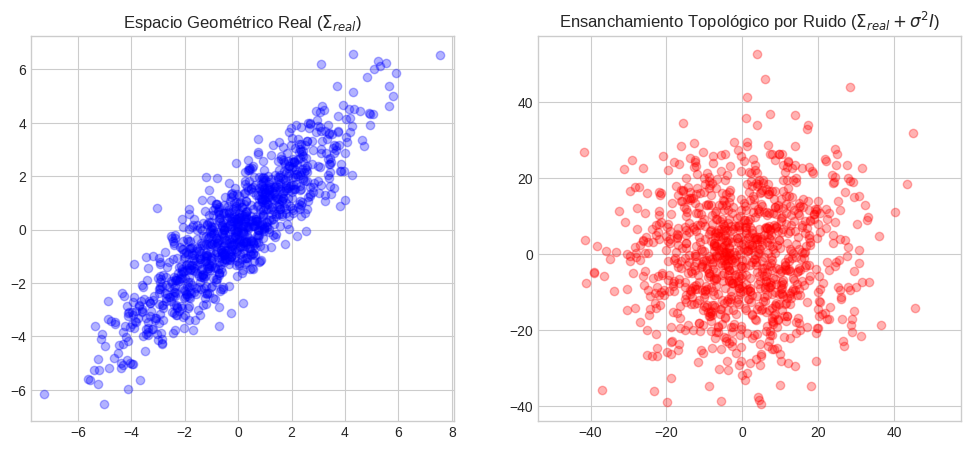

In [ ]:
# Simulación Sintética de Ruido e Inflación Espectral
np.random.seed(42)

# 1. Generar X_real (Distribución elipsoidal 2D altamente correlacionada)
n_samples = 1000
mean_real = [0, 0]
cov_real = [[5.0, 4.5],
            [4.5, 5.0]]
X_real = np.random.multivariate_normal(mean_real, cov_real, n_samples)

# 2. Generar Ruido Isotrópico (sigma^2 = 2.0)
sigma2 = 200.0
noise = np.random.normal(0, np.sqrt(sigma2), (n_samples, 2))

# 3. Datos Observados
X_obs = X_real + noise

# 4. Cálculo de Matrices de Covarianza
Sigma_real = np.cov(X_real, rowvar=False)
Sigma_obs = np.cov(X_obs, rowvar=False)

# 5. Descomposición Espectral (Autovalores)
eigvals_real, _ = la.eigh(Sigma_real)
eigvals_obs, _ = la.eigh(Sigma_obs)

print("--- ANÁLISIS ESPECTRAL ---")
print(f"Autovalores de Sigma_real: {eigvals_real}")
print(f"Autovalores de Sigma_obs : {eigvals_obs}")
print(f"Diferencia teórica esperada (sigma^2) : {sigma2}")
print(f"Diferencia empírica (Inflación)     : {eigvals_obs - eigvals_real}")

# 6. Interpretación Geométrica
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_real[:, 0], X_real[:, 1], alpha=0.3, color='blue', label='Señal Pura')
ax[0].set_title('Espacio Geométrico Real ($\\Sigma_{real}$)')
ax[0].axis('equal')

ax[1].scatter(X_obs[:, 0], X_obs[:, 1], alpha=0.3, color='red', label='Señal + Ruido')
ax[1].set_title(f'Ensanchamiento Topológico por Ruido ($\\Sigma_{{real}} + \\sigma^2 I$)')
ax[1].axis('equal')
plt.show()

---


### Reto Opcional (Bloque I):

Implemente un filtro de suavizado espacial y demuestre empíricamente si la matriz de covarianza resultante logra converger nuevamente hacia $\Sigma_{real}$.



## BLOQUE II: VALORES FALTANTES Y COLAPSO DE VARIANZA




### 1. Objetivos Matemáticos

* Clasificar probabilísticamente la falta de datos: MCAR, MAR, MNAR.
* Demostrar algebraicamente que la imputación por media destruye la matriz de covarianza cruzada.
* Contrastar la imputación univariada contra la imputación por regresión multivariada.

### 2. Demostraciones Matemáticas

**Mecanismos de Ausencia:**
Sea una matriz $M$ tal que $M_{ij}=1$ si $X_{ij}$ es missing.

* **MCAR:** $P(M | X_{obs}, X_{mis}) = P(M)$. El error es uniforme y ciego.
* **MAR:** $P(M | X_{obs}, X_{mis}) = P(M | X_{obs})$. (Ej. Los sensores fallan solo cuando la temperatura registrada es baja).
* **MNAR:** $P(M | X_{obs}, X_{mis}) = P(M | X_{mis})$. El sesgo oculto más peligroso.

**Teorema de la Destrucción de Covarianza:**
Sea una variable $X_j$ con $n$ datos observados (media $\mu_{obs}$ y varianza $\sigma^2_{obs}$) y $m$ datos faltantes imputados con $\mu_{obs}$.
La varianza del conjunto imputado completo es:


$$\sigma^2_{imp} = \frac{1}{n+m-1} \left( \sum_{i=1}^n (x_i - \mu_{obs})^2 + \sum_{k=1}^m (\mu_{obs} - \mu_{obs})^2 \right)$$


Asumiendo muestras grandes ($n+m \approx n+m-1$):


$$\sigma^2_{imp} \approx \frac{1}{n+m} \sum_{i=1}^n (x_i - \mu_{obs})^2 = \frac{n}{n+m} \sigma^2_{obs}$$


*Conclusión:* Como $\frac{n}{n+m} < 1$, imputar por la media **comprime el espacio métrico**, subestimando el riesgo estructural y deformando los hiperplanos de decisión de clasificadores probabilísticos como Naive Bayes.

### 3. Implementación Computacional

---

# [Datos faltantes]

In [ ]:
# 1. Cargar dataset real y forzar MCAR
data = fetch_california_housing(as_frame=True)
df = data.frame[['MedInc', 'HouseAge']].copy()

# Guardar matriz de covarianza original
cov_original = df.cov()

# Introducir 40% de NaNs en 'MedInc' completamente al azar (MCAR)
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.4
df_mcar = df.copy()
df_mcar.loc[mask, 'MedInc'] = np.nan

# 2. Imputación Univariada (

    a)
imputer_mean = SimpleImputer(strategy='mean')
df_mean_imp = pd.DataFrame(imputer_mean.fit_transform(df_mcar), columns=df.columns)
cov_mean = df_mean_imp.cov()

# 3. Imputación Multivariada (Regresión)
imputer_multi = IterativeImputer(random_state=42)
df_multi_imp = pd.DataFrame(imputer_multi.fit_transform(df_mcar), columns=df.columns)
cov_multi = df_multi_imp.cov()

# 4. Análisis Espectral del Colapso
print("--- VARIANZA DE 'MedInc' ---")
print(f"1. Original             : {cov_original.loc['MedInc', 'MedInc']:.4f}")
print(f"2. Imputación por Media : {cov_mean.loc['MedInc', 'MedInc']:.4f}  <-- ¡Colapso analítico!")
print(f"3. Imputación Múltiple  : {cov_multi.loc['MedInc', 'MedInc']:.4f}")

print("\n--- COVARIANZA CRUZADA (MedInc vs HouseAge) ---")
print(f"1. Original             : {cov_original.loc['MedInc', 'HouseAge']:.4f}")
print(f"2. Imputación por Media : {cov_mean.loc['MedInc', 'HouseAge']:.4f}  <-- Destrucción de topología!")
print(f"3. Imputación Múltiple  : {cov_multi.loc['MedInc', 'HouseAge']:.4f}")

--- VARIANZA DE 'MedInc' ---
1. Original             : 3.6093
2. Imputación por Media : 2.1899  <-- ¡Colapso analítico!
3. Imputación Múltiple  : 2.2065

--- COVARIANZA CRUZADA (MedInc vs HouseAge) ---
1. Original             : -2.8461
2. Imputación por Media : -1.5576  <-- Destrucción de topología!
3. Imputación Múltiple  : -2.5785


## BLOQUE III: INTEGRACIÓN Y MULTICOLINEALIDAD

### 1. Objetivos Matemáticos

* Analizar los efectos del rango matricial deficiente tras concatenación.
* Demostrar por qué la dependencia lineal causa la explosión de los estimadores paramétricos.
* Introducir la estabilización espectral mediante Regularización Tikhonov (Ridge).

### 2. Demostraciones Matemáticas

Si concatenamos bases de datos con información redundante, formamos combinaciones lineales en las columnas de $X$: $X\mathbf{v} = \mathbf{0}$ para algún vector $\mathbf{v} \neq \mathbf{0}$. Esto significa que el *espacio nulo* de $X$ no es trivial.

**Teorema de la Falla de Inversión:**
En modelos como OLS, debemos calcular la inversa de la matriz de Gram $(X^T X)^{-1}$.
Si existe redundancia lineal, $X\mathbf{v} = \mathbf{0} \implies X^T X \mathbf{v} = \mathbf{0}$.
Por tanto, $\mathbf{v}$ es un autovector de $X^T X$ con autovalor $\lambda = 0$.
Sabiendo que el determinante es el producto de los autovalores:


$$\det(X^T X) = \prod_{i=1}^d \lambda_i = 0$$


Una matriz con determinante nulo es **singular (no invertible)**. Computacionalmente, incluso si $\lambda \to 0$ (condicionamiento pobre), el número de condición $\kappa = \frac{\lambda_{max}}{\lambda_{min}} \to \infty$, causando inestabilidad catastrófica flotante.

**Estabilización de Ridge (Tikhonov):**
Si sumamos una constante $\alpha$ a la diagonal: $(X^T X + \alpha I)$.
El nuevo autovalor correspondiente a $\mathbf{v}$ será $\lambda_{new} = 0 + \alpha = \alpha > 0$. La matriz es invertible de nuevo.

---

# [Integracion y Multicolinealidad]

In [ ]:
# Generación de Multicolinealidad Exacta
n = 500
x1 = np.random.randn(n)
x2 = np.random.randn(n)
x3 = 2.0 * x1 - 1.5 * x2  # x3 es combinación lineal perfecta de x1 y x2

X_colin = np.vstack([x1, x2, x3]).T
Gram_matrix = X_colin.T @ X_colin

print("--- ANÁLISIS DE MULTICOLINEALIDAD ---")
# 1. Calcular autovalores
eigvals_gram, _ = la.eigh(Gram_matrix)
print(f"Autovalores de X^T X: {eigvals_gram}")

# 2. Número de condición
kappa = np.max(eigvals_gram) / np.min(np.abs(eigvals_gram))
print(f"Número de condición (Kappa): {kappa:.2e} (Tiende a infinito)")

# 3. Intentar invertir (Fallará algebraicamente, numpy lo hace mediante pseudo-inversa o tira advertencia,
# demostraremos el fallo exacto intentando invertir matriz singular en scipy puro)
try:
    inv_gram = la.inv(Gram_matrix)
except la.LinAlgError as e:
    print(f"FALLO DE INVERSIÓN DEMOSTRADO: {e}")

# 4. Solución: Regularización Ridge
alpha = 0.1
Ridge_matrix = Gram_matrix + alpha * np.eye(3)
inv_ridge = la.inv(Ridge_matrix)
print("\nInversión exitosa aplicando Ridge (X^T X + alpha I)^-1")
print(f"Nuevos autovalores: {la.eigh(Ridge_matrix)[0]}")

--- ANÁLISIS DE MULTICOLINEALIDAD ---
Autovalores de X^T X: [   0.      489.6283 3405.0955]
Número de condición (Kappa): 4.85e+16 (Tiende a infinito)

Inversión exitosa aplicando Ridge (X^T X + alpha I)^-1
Nuevos autovalores: [   0.1     489.7283 3405.1955]


## BLOQUE IV: TRANSFORMACIÓN Y ESCALAMIENTO

### 1. Objetivos Matemáticos

* Demostrar la invarianza de la covarianza bajo traslación.
* Formular matemáticamente la estandarización y sus implicancias en la tasa de convergencia del gradiente.
* ⚠️ **ADVERTENCIA DE DATA LEAKAGE**: Comprender por qué los parámetros de la transformación de $\mathbb{R}^d$ deben ser calculados estrictamente sobre el conjunto de entrenamiento.

### 2. Demostraciones Matemáticas

**Centralización (Mean Centering):**
Sea la matriz centralizada $X_c = X - \mathbf{1}\boldsymbol{\mu}^T$.
La suma de sus desviaciones es analíticamente $\mathbf{0}$:


$$\sum_{i=1}^n (\mathbf{x}_i - \boldsymbol{\mu}) = \sum \mathbf{x}_i - n\boldsymbol{\mu} = n\boldsymbol{\mu} - n\boldsymbol{\mu} = \mathbf{0}$$


Por lo tanto, $\Sigma = \frac{1}{n-1} X_c^T X_c$. (La matriz de covarianza es equivalente a la matriz de Gram del espacio centralizado).

**Transformación Lineal Completa:**
Sea una matriz de pesos $W$ aplicada a $X$ tal que $Y = XW^T$ (asumiendo proyecciones por fila). Si $X$ está centralizada:


$$\Sigma_Y = \frac{1}{n-1} Y^T Y = \frac{1}{n-1} (W X^T)(X W^T) = W \left( \frac{1}{n-1} X^T X \right) W^T = W \Sigma_X W^T$$

**Conexión con el Gradiente (Desigualdad de Rayleigh):**
Para minimizar el riesgo empírico $\mathcal{L}(\theta)$ en un modelo lineal, la curvatura del hiperparaboloide (el Hessiano) es $H = X^T X$.
La convergencia del Descenso de Gradiente está acotada por el cociente de Rayleigh de $H$, el cual dictamina el número de condición $\kappa$.
Si transformamos el espacio aplicando un *Z-score* perfecto (donde $\Sigma_Y = I$), $\kappa \to 1$. El hiperparaboloide se vuelve perfectamente esférico y el gradiente negativo apunta *directamente* al mínimo global, reduciendo iteraciones de $O(10^4)$ a $O(10)$.

---

# [Transformacion y escalamineto]

In [ ]:
# DATA LEAKAGE: El error matemático capital
# Forma INCORRECTA: Aplicar scaler.fit_transform(X_total)
# Forma CORRECTA: scaler.fit(X_train) -> scaler.transform(X_train) y scaler.transform(X_test)

# Comparativa de Condicionamiento: Crudo vs Z-Score
X_housing = data.data.values # Dataset con escalas masivamente dispares (Edad vs Ingresos vs Habitaciones)

# 1. Matriz de Gram Cruda
X_c = X_housing - np.mean(X_housing, axis=0)
Gram_raw = X_c.T @ X_c
kappa_raw = np.linalg.cond(Gram_raw)

# 2. Transformación Z-score matricial
scaler = StandardScaler()
X_z = scaler.fit_transform(X_housing)
Gram_z = X_z.T @ X_z
kappa_z = np.linalg.cond(Gram_z)

print("--- TOPOLOGÍA DEL GRADIENTE (Condicionamiento del Hessiano) ---")
print(f"Condicionamiento Datos Crudos  (Kappa) : {kappa_raw:.2e} (Oscilación caótica)")
print(f"Condicionamiento Z-Score       (Kappa) : {kappa_z:.2e} (Convergencia acelerada)")

--- TOPOLOGÍA DEL GRADIENTE (Condicionamiento del Hessiano) ---
Condicionamiento Datos Crudos  (Kappa) : 4.21e+07 (Oscilación caótica)
Condicionamiento Z-Score       (Kappa) : 4.45e+01 (Convergencia acelerada)


## BLOQUE V: DISTANCIAS AVANZADAS (GEOMETRÍA MÉTRICA)

### 1. Objetivos Matemáticos

* Diferenciar el espacio ortogonal del espacio correlacionado.
* Demostrar la equivalencia entre la distancia Euclidiana en el espacio blanqueado y la métrica de Mahalanobis.

### 2. Demostraciones Matemáticas

La distancia Euclidiana estándar asume isotropía e independencia ortogonal:


$$d_E(\mathbf{x}, \boldsymbol{\mu}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T I (\mathbf{x} - \boldsymbol{\mu})}$$

La **Distancia de Mahalanobis** pondera el espacio por la forma estructural (matriz de covarianza inversa):


$$d_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

**Teorema de Equivalencia Espectral (Whitening / Blanqueamiento):**
Definimos una transformación que elimina toda correlación y hace la varianza unitaria. Dado que $\Sigma$ es simétrica definida positiva, podemos calcular su raíz $\Sigma^{-1/2}$.
Proyectamos un vector: $\mathbf{z} = \Sigma^{-1/2} (\mathbf{x} - \boldsymbol{\mu})$.
Calculemos la norma L2 (Euclidiana) de este vector en el nuevo espacio latente:


$$||\mathbf{z}||_2^2 = \mathbf{z}^T \mathbf{z} = (\Sigma^{-1/2}(\mathbf{x} - \boldsymbol{\mu}))^T (\Sigma^{-1/2}(\mathbf{x} - \boldsymbol{\mu}))$$

$$= (\mathbf{x} - \boldsymbol{\mu})^T (\Sigma^{-1/2})^T \Sigma^{-1/2} (\mathbf{x} - \boldsymbol{\mu})$$


Por simetría, $(\Sigma^{-1/2})^T = \Sigma^{-1/2}$:


$$= (\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu}) = d_M(\mathbf{x})^2$$


*Conclusión rigurosa:* La distancia de Mahalanobis es exactamente la distancia Euclidiana si el espacio vectorial hubiese sido rotado por sus Componentes Principales (PCA) y aplastado para forzar esfericidad ($\Sigma = I$).

---

# [Distancias avanzadas]

In [ ]:
from scipy.spatial.distance import mahalanobis

# Generar nube correlacionada
np.random.seed(0)
cov_ellipsoid = [[10, 8], [8, 10]]
X_ellip = np.random.multivariate_normal([0, 0], cov_ellipsoid, 500)
mu_ellip = np.mean(X_ellip, axis=0)
inv_cov = la.inv(np.cov(X_ellip, rowvar=False))

# Crear un Outlier que parece normal en cada eje individualmente, pero rompe la correlación
outlier = np.array([-4, 4])

# Distancia Euclidiana vs Mahalanobis
dist_E = la.norm(outlier - mu_ellip)
dist_M = mahalanobis(outlier, mu_ellip, inv_cov)

print("--- ANÁLISIS MÉTRICO DE OUTLIERS ---")
print(f"Distancia Euclídea   : {dist_E:.4f} (Subestima la anomalía al ignorar la topología)")
print(f"Distancia Mahalanobis: {dist_M:.4f} (Refleja la verdadera rareza probabilística)")

# Visualización
plt.figure(figsize=(7, 5))
plt.scatter(X_ellip[:, 0], X_ellip[:, 1], alpha=0.5, label='Distribución Normal')
plt.scatter(outlier[0], outlier[1], color='red', s=100, marker='X', label='Outlier')
plt.plot([0, outlier[0]], [0, outlier[1]], 'r--', alpha=0.5)
plt.title('Mahalanobis: El Outlier rompe la estructura del Eigenvector')
plt.axis('equal')
plt.legend()
plt.show()

## BLOQUE VI: CIERRE Y REFLEXIÓN ESTRATÉGICA

### Pipeline KDD Riguroso

Como hemos demostrado algebraicamente:

1. **"Garbage In, Garbage Out" es un axioma probabilístico:** Si no manejan la imputación con cuidado, colapsarán la covarianza cruzada y sus modelos predictivos fallarán.
2. **El Condicionamiento es el Techo de Rendimiento:** Un $\kappa(X^T X)$ tendiendo a infinito destruirá la invertibilidad y arruinará la convergencia convexa.
3. **El espacio es maleable:** Mahalanobis, PCA y Whitening son solo facetas de la misma operación: domar el hiperespacio multiplicando por $\Sigma^{-1/2}$ o subespacios de autovectores.

### Retos Opcionales Avanzados

1. **Para el investigador:** Desarrolle un script en numpy que realice la imputación múltiple MICE manualmente operando con la ecuación normal de mínimos cuadrados $(X_{-j}^T X_{-j})^{-1} X_{-j}^T X_j$.
2. **Para el ingeniero:** Demuestre empíricamente cómo el escalamiento Z-score puede agravar la sensibilidad a outliers en lugar de mejorarla. Compare en Colab contra un `RobustScaler` (basado en cuantiles).
3. **Para el teórico:** Partiendo de $X^T X$, demuestre que todos los autovalores de la matriz de covarianza son no-negativos (La matriz es Semi-Definida Positiva).